In [ ]:
import numpy as np

np.random.seed(42)

A = np.random.randn(6, 6)
cov = A.T @ A

eigvals, eigvecs = np.linalg.eigh(cov)
eigvals[-1] = 1e-12

cov_ill = eigvecs @ np.diag(eigvals) @ eigvecs.T


Covariance matrix created


In [ ]:
cond_num = np.linalg.cond(cov_ill)

print(f'Condition number: {cond_num:.3e}')

if cond_num > 1e12:
    print('Severely ill-conditioned')
elif cond_num > 1e8:
    print('Moderately ill-conditioned')
else:
    print('Well-conditioned')

Condition number: 8.819e+12
Severely ill-conditioned


In [3]:
try:
    inv_bad = np.linalg.inv(cov_ill)
    print('Inverse computed')
except Exception as e:
    print('Failed:', e)

Inverse computed


In [4]:
eigvals, eigvecs = np.linalg.eigh(cov_ill)
eps = 1e-6
eigvals_clipped = np.clip(eigvals, eps, None)

cov_stable = eigvecs @ np.diag(eigvals_clipped) @ eigvecs.T

print('Before:', np.linalg.cond(cov_ill))
print('After:', np.linalg.cond(cov_stable))

Before: 8819027140352.51
After: 8817334.480809543


In [5]:
inv_stable = np.linalg.inv(cov_stable)
print('Stable inversion done')

Stable inversion done


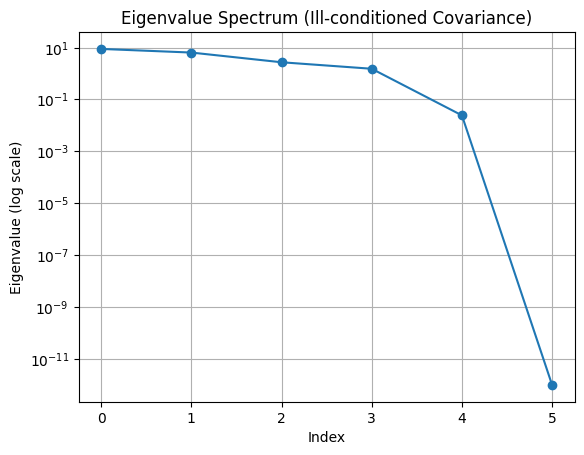

In [6]:
import matplotlib.pyplot as plt

eigvals = np.linalg.eigvalsh(cov_ill)

plt.figure()
plt.semilogy(sorted(eigvals)[::-1], marker='o')
plt.title("Eigenvalue Spectrum (Ill-conditioned Covariance)")
plt.xlabel("Index")
plt.ylabel("Eigenvalue (log scale)")
plt.grid(True)
plt.show()

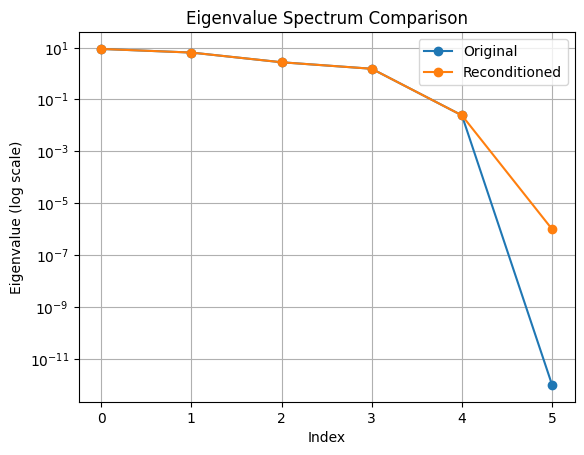

In [7]:
eigvals2 = np.linalg.eigvalsh(cov_stable)

plt.figure()
plt.semilogy(sorted(eigvals)[::-1], marker='o', label="Original")
plt.semilogy(sorted(eigvals2)[::-1], marker='o', label="Reconditioned")

plt.title("Eigenvalue Spectrum Comparison")
plt.xlabel("Index")
plt.ylabel("Eigenvalue (log scale)")
plt.legend()
plt.grid(True)
plt.show()

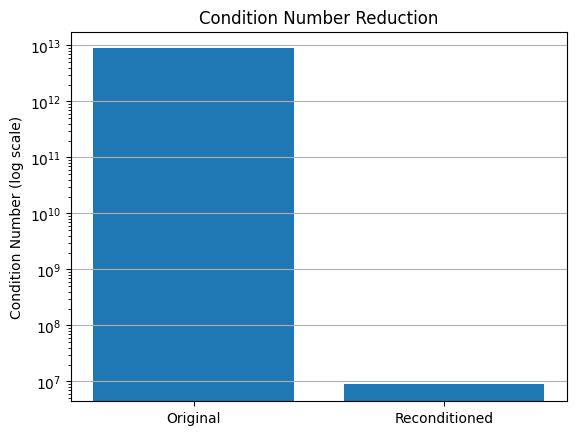

In [8]:
conds = [np.linalg.cond(cov_ill), np.linalg.cond(cov_stable)]

plt.figure()
plt.bar(["Original", "Reconditioned"], conds)
plt.yscale("log")
plt.title("Condition Number Reduction")
plt.ylabel("Condition Number (log scale)")
plt.grid(True, axis='y')
plt.show()